In [ ]:
# !python3 --version

# # Use in Google Colab to install the package and depdencies directly from GitHub
# !pip install "git+https://github.com/adrianstanea/NLP-Topic-Modeling@main"

Python 3.12.12
zsh:1: command not found: pip


In [1]:
### print style, ANSI colors

CYAN = "\033[96m"
GREEN = "\033[92m"
YELLOW = "\033[93m"
ORANGE = "\033[38;5;214m"
MAGENTA = "\033[95m"
BLUE = "\033[94m"
RED = "\033[91m"
PURPLE = "\033[95m"
BRIGHT_PURPLE = "\033[35m"
RESET = "\033[0m"

In [2]:
# import pandas as pd
# import warnings
# warnings.filterwarnings("ignore") # Clean up output for presentation

# # Visualization tools
# import pyLDAvis.lda_model

# # Neural Tools
# from bertopic import BERTopic
# from transformers import AutoModel, AutoTokenizer

# # LDA Tools (ArtificiAI)
# try:
#     from artifici_lda.lda_service import train_lda_pipeline_default
# except ImportError:
#     print("Error: artifici_lda not found. Please install via: pip install git+https://github.com/ArtificiAI/Multilingual-Latent-Dirichlet-Allocation-LDA.git")

## Data Exploration

### Dataset

In [3]:
from nlp_topic_modeling.data.loaders import load_MOROCO

df, columns = load_MOROCO()
print(f"\nDataset shape and columns:")
print(f"\tShape: {df.shape}")
print(f"\tColumns: {columns}")

# To test faster keep only a subset of the data: around 10% of the original data with stratification
df = df \
    .groupby('category', group_keys=False)\
    .apply(lambda x: x.sample(frac=0.001, random_state=42))

print(f"\nSubset dataset shape:")
print(f"\tShape: {df.shape}")

/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Loading MOROCO from Hugging Face ---
	Loaded 21719 documents.

Dataset shape and columns:
	Shape: (21719, 2)
	Columns: ['category', 'sample']

Subset dataset shape:
	Shape: (22, 2)


/tmp/ipykernel_30171/3124132897.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.001, random_state=42))



Class distribution:
  1.0: 6.0 documents (27.27%)
  2.0: 6.0 documents (27.27%)
  4.0: 4.0 documents (18.18%)
  5.0: 3.0 documents (13.64%)
  3.0: 2.0 documents (9.09%)
  0.0: 1.0 documents (4.55%)


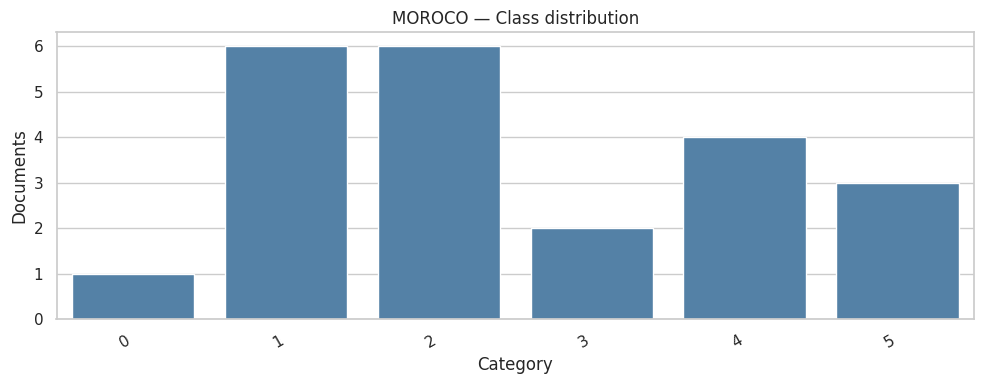

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

class_counts = (
    df["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
    .assign(percentage=lambda x: (x["count"] / x["count"].sum() * 100).round(2))
)

print("\nClass distribution:")
for _, row in class_counts.iterrows():
    print(f"  {row['category']}: {row['count']} documents ({row['percentage']}%)")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 4))
ax = sns.barplot(data=class_counts, x="category", y="count", color="steelblue")
ax.set_title("MOROCO — Class distribution")
ax.set_xlabel("Category")
ax.set_ylabel("Documents")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [5]:
import numpy as np

N = 3
# np.random.seed(42)

random_indices = np.random.choice(df.index, size=N, replace=False)

for idx, (index, row) in enumerate(df.loc[random_indices].iterrows()):
    print(f"\nSample {idx + 1}:")

    # text
    print(f"{CYAN}\nText: {RESET}{row['sample']}")
    print(f"{BLUE}\nCategory: {RESET}{row['category']}")

    # Break after N iterations
    if idx + 1 >= N:
        break


Sample 1:

Text: Ambiţiile umane de a călători pe $NE$ sau în altă parte a $NE$ $NE$ se vor ”întâlni”cu una dintre cele mai importante provocări, cum să rămână sănătoşi în cosmos pentru perioade lungi de timp, scrie $NE$ . N$NE$ estimează că durează cel puţin 150 de zile pentru om ca să ajungă pe $NE$ . În această perioadă de timp, fără beneficiile câmpului magnetic protector al $NE$ el va fi expus la mai mulţi factori nocivi, printre care şi radiaţiile cosmice . Din păcate, unele dintre cele mai recente cercetări cu privire la efectele petrecerii timpului în spaţiul cosmic nu are constatări foarte pozitive . Un studiu recent a ajuns la concluzia că şoarecii aflaţi la bordul navetei spaţiale $NE$ au revenit pe $NE$ cu semnele precoce ale bolii hepatice, în condiţiile în care micile animale au ”lipsit” de pe planetă mai puţin de două săptămâni . După ce s - au aflat 13 . 5 zile la bordul navetei în timpul zborului său final în 2011, şoarecii au fost studiaţi de o echipă de oameni de şt

In [7]:
# Create a new column with the number of characters in each document
df["char_count"] = df["sample"].apply(len)
df["char_count"].describe()

count      22.000000
mean     1556.363636
std      1020.093765
min       226.000000
25%       951.500000
50%      1500.500000
75%      1702.000000
max      4534.000000
Name: char_count, dtype: float64

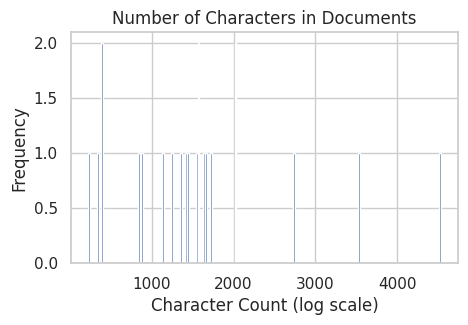

In [8]:
df['char_count'].hist(bins=200, figsize=(5, 3))
plt.title('Number of Characters in Documents')
plt.xlabel('Character Count (log scale)')
plt.ylabel('Frequency')
plt.show()

## Data Preprocessing

### Text Preprocessing

In [11]:
from nltk.corpus import stopwords
import nltk
from stop_words import get_stop_words
import stopwordsiso


nltk.download('stopwords')

ro_stopwords_nltk = stopwords.words('romanian')
print(f"NLTK Romanian stopwords count: {len(ro_stopwords_nltk)}")
ro_stopwords_sw = get_stop_words('romanian')
print(f"stop-words Romanian stopwords count: {len(ro_stopwords_sw)}")

# Retrieve stopwords for Romanian using its ISO 639-1 code
ro_stopwords_ISO = stopwordsiso.stopwords("ro")
print(f"stopwordsiso Romanian stopwords count: {len(ro_stopwords_ISO)}")

RO_STOPWORDS = list(set(ro_stopwords_nltk + ro_stopwords_sw + list(ro_stopwords_ISO)))
print(f"Combined Romanian stopwords count: {len(RO_STOPWORDS)}")
print(RO_STOPWORDS)

NLTK Romanian stopwords count: 356
stop-words Romanian stopwords count: 268
stopwordsiso Romanian stopwords count: 434
Combined Romanian stopwords count: 448
['îi', 'vreme', 'cand', 'cite', 'atatea', 'capat', 'săi', 'frumos', 'bună', 'ălea', 'totul', 'cui', 'alt', 'x', 'ului', 'fel', 'aş', 'ala', 'mare', 'ul', 'ma', 'una', 'aici', 'ci', 'din', 'nostri', 'cu', 'zice', 'mâine', 'când', 'daca', 'ati', 'nicăieri', 'rog', 'citiva', 'aiurea', 'aia', 'acelea', 'acord', 'acum', 'sa-mi', 'intr-un', 'acesta', 'plus', 'fim', 'aibă', 'aceştia', 'puţin', 'niste', 'acelasi', 'alta', 'care', 'dau', 'fiţi', 'catre', 'uneia', 'ieri', 'inapoi', 'să', 'imi', 'atat', 'ea', 'multi', 'sint', 'altfel', 'încotro', 'mie', 'primul', 'vi', 'oricând', 'atitea', 'cat', 'încât', 'ai', 'acela', 'aceasta', 'doi', 'e', 'degraba', 'câte', 'o', 'fii', 'uneori', 'c', 'mulţi', 'astfel', 'u', 'ce', 'decit', 'patru', 'altceva', 'ţie', 'toata', 'noi', 'un', 'cât', 'sută', 'despre', 'sunteţi', 'pe', 'v', 'dată', 'am', 'oricîn

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/astanea/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [13]:
from pprint import pprint
from artifici_lda.lda_service import train_lda_pipeline_default


transformed_comments, top_comments, _1_grams, _2_grams = train_lda_pipeline_default(
    df['sample'].to_list(),
    n_topics=df['category'].nunique(),
    stopwords=RO_STOPWORDS,
    language='romanian')

pprint(transformed_comments)
pprint(top_comments)
pprint(_1_grams)
pprint(_2_grams)

array([[0.01667036, 0.91623284, 0.01681621, 0.01684087, 0.0167724 ,
        0.01666732],
       [0.93040971, 0.01391588, 0.0139122 , 0.01392403, 0.01394101,
        0.01389717],
       [0.00757876, 0.96204241, 0.00761062, 0.00759968, 0.00759261,
        0.00757591],
       [0.00209574, 0.0020988 , 0.98953515, 0.00208887, 0.00209249,
        0.00208894],
       [0.00304148, 0.98478984, 0.00304143, 0.00304498, 0.00304232,
        0.00303995],
       [0.01113078, 0.01121802, 0.01122803, 0.0111184 , 0.9441504 ,
        0.01115437],
       [0.00265077, 0.00265787, 0.00265702, 0.00266231, 0.98671137,
        0.00266066],
       [0.00176042, 0.00176082, 0.4978244 , 0.00175967, 0.00176665,
        0.49512805],
       [0.98139922, 0.00372645, 0.00372174, 0.00371614, 0.0037281 ,
        0.00370836],
       [0.00121973, 0.99389441, 0.00122002, 0.00122182, 0.00122362,
        0.0012204 ],
       [0.00183875, 0.00184621, 0.00183993, 0.00183781, 0.99080192,
        0.00183538],
       [0.00177494, 0

#### Removing Stop Words

In [ ]:
from artifici_lda.data_utils import get_params_from_prefix_dict


stopwords_params = get_params_from_prefix_dict(
    param_prefix="stopwords__",
    lda_pipeline_params=LDA_PIPELINE_PARAMS_WORDS)

## Method : LDA

['a', 'abia', 'acea', 'aceasta', 'această', 'aceea', 'aceeasi', 'acei', 'aceia', 'acel', 'acela', 'acelasi', 'acele', 'acelea', 'acest', 'acesta', 'aceste', 'acestea', 'acestei', 'acestia', 'acestui', 'aceşti', 'aceştia', 'adica', 'ai', 'aia', 'aibă', 'aici', 'al', 'ala', 'ale', 'alea', 'alt', 'alta', 'altceva', 'altcineva', 'alte', 'altfel', 'alti', 'altii', 'altul', 'am', 'anume', 'apoi', 'ar', 'are', 'as', 'asa', 'asta', 'astea', 'astfel', 'asupra', 'atare', 'atat', 'atata', 'atatea', 'atatia', 'ati', 'atit', 'atita', 'atitea', 'atitia', 'atunci', 'au', 'avea', 'avem', 'aveţi', 'avut', 'aş', 'aţi', 'ba', 'ca', 'cam', 'cand', 'care', 'careia', 'carora', 'caruia', 'cat', 'catre', 'ce', 'cea', 'ceea', 'cei', 'ceilalti', 'cel', 'cele', 'celor', 'ceva', 'chiar', 'ci', 'cind', 'cine', 'cineva', 'cit', 'cita', 'cite', 'citeva', 'citi', 'citiva', 'cu', 'cui', 'cum', 'cumva', 'cât', 'câte', 'câtva', 'câţi', 'cînd', 'cît', 'cîte', 'cîtva', 'cîţi', 'că', 'căci', 'cărei', 'căror', 'cărui', 'căt

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/astanea/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
print("\n--- Method 1: Training LDA Model (Statistical) ---")

docs_list = df['sample'].tolist()
n_topics = df['category'].nunique()


--- Method 1: Training LDA Model (Statistical) ---


In [ ]:
import artifici_lda


from artifici_lda.logic.stemmer import Stemmer
from snowballstemmer import stemmer

stemmer = Stemmer(language='romanian')

 - Docs here; https://github.com/ArtificiAI/Multilingual-Latent-Dirichlet-Allocation-LDA/blob/master/Multilingual-LDA-Pipeline-Tutorial.ipynb 

In [ ]:
from nlp_topic_modeling.lda import lda_pipeline
from nlp_topic_modeling.lda.config import ROMANIAN

# This method uses "Inverse Stemming" to cluster topics based on word roots but returns readable representatives.

transformed_docs, top_docs, unigrams, bigrams = lda_pipeline(
    docs_list=docs_list,
    n_topics=n_topics,
    language=ROMANIAN,
    stopwords=RO_STOPWORDS
)

In [ ]:
# Train the pipeline
transformed_docs, top_docs, unigrams, bigrams = train_lda_pipeline_default(
    docs_list,
    n_topics=6,
    stopwords=RO_STOPWORDS,
    language='romanian'
)

# Display results
print("\n[LDA] Top Topic Keywords (Bigrams):")
for i, topic in enumerate(bigrams):
    # Print top 5 bigrams for the topic
    clean_grams = [t[0] for t in topic[:5]]
    print(f"Topic {i}: {clean_grams}")


--- Method 1: Training LDA Model (Statistical) ---


114.29s - Error patching args (debugger not attached to subprocess).
Traceback (most recent call last):
  File "/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 541, in patch_args
    new_args.append(_get_python_c_args(host, port, code, unquoted_args, SetupHolder.setup))
                    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.12/site-packages/debugpy/_vendored/pydevd/_pydev_bundle/pydev_monkey.py", line 193, in _get_python_c_args
    if "__future__" in code:
       ^^^^^^^^^^^^^^^^^^^^
TypeError: a bytes-like object is required, not 'str'
0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will pr

## Method 2: Neural Embeddings (RoBERT + BERTopic)

The Algorithm - BERTopic

In [ ]:
from transformers import AutoModel, AutoTokenizer, AutoModel
from bertopic import BERTopic

print("--- Training BERTopic Model ---")

model_name = "readerbench/RoBERT-base"

topic_model = BERTopic(
    embedding_model=model_name,
    language="romanian",
    min_topic_size=2,
    verbose=True
)

# Fit and Transform
topics, probs = topic_model.fit_transform(docs_list)

# Display Info
print(topic_model.get_topic_info().head())

In [ ]:
from bertopic import BERTopic
from transformers import AutoModel, AutoTokenizer

# Initialize RoBERT-base as the embedding backend
model_name = "readerbench/RoBERT-base"
topic_model = BERTopic(embedding_model=model_name, language="multilingual")
topics, probs = topic_model.fit_transform(docs_list)

In [1]:
# pytorch
from transformers import AutoModel, AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("readerbench/RoBERT-base")
model = AutoModel.from_pretrained("readerbench/RoBERT-base")
inputs = tokenizer("exemplu de propoziție", return_tensors="pt")
outputs = model(**inputs)

/home/astanea/git-repos/adrianstanea/NLP-Topic-Modeling/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
outputs

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.1799, -0.0813,  0.8690,  ..., -0.2820,  0.0934,  0.7427],
         [ 0.5068,  0.4884,  0.1603,  ...,  0.3275,  0.6655, -0.3906],
         [ 0.6516,  0.4548, -0.2504,  ...,  0.1670,  0.4344,  0.1669],
         ...,
         [ 0.2018, -0.9343, -0.4237,  ...,  1.2236, -0.0991, -0.1604],
         [-0.6006, -0.3131,  0.0780,  ...,  0.5276, -0.4769,  0.3721],
         [ 0.0914, -0.1258,  0.0552,  ...,  0.1965, -0.1086,  0.2170]]],
       grad_fn=<NativeLayerNormBackward0>), pooler_output=tensor([[-9.8939e-01, -3.9414e-01,  3.7290e-01,  9.7404e-01, -1.6963e-01,
          5.5492e-01,  1.1029e-01, -2.8783e-01,  3.9374e-01,  1.7747e-01,
          3.0243e-01,  6.1234e-02, -4.5448e-01, -1.2506e-01,  1.5203e-01,
         -3.6685e-01, -6.6735e-01,  7.7938e-01, -9.8936e-01,  4.1359e-01,
          3.3446e-01,  2.6447e-01, -2.0789e-01,  4.5235e-01, -4.2164e-01,
         -7.6997e-01, -3.4082e-01, -9.6521e-01, -8.3696e-01, -2.721